<a href="https://colab.research.google.com/github/Sosswood/Machine-Learning/blob/main/Individual_Project_Book_Crossing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I chose to use the Book Crossing dataset from Kaggle.  My first love is theatre, but the available datasets for this were disappointing in their lack of both size and detail.  I liked the MovieLens approach, but was concerned that the particular dataset had been worked with extensively and I would have little new insight to offer.  I am an avid reader - never seen without a book in my hand - and so Book Crossing seemed like a fitting dataset for me to work with.  I used to work in publishing, so I'm familiar with ISBNs and how they're put together.

It has ratings from almost 3k users, over 1m ratings overall, across almost 3k books.  This means that many users have rated multiple books.

How does a traditional matrix-factorisation recommender compare with a deep-learning recommender for predicting Book-Crossing user ratings, and which is more appropriate for real-world deployment when performance, explainability, bias, ethics and computational complexity are considered?

First, I'll import the data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("somnambwl/bookcrossing-dataset")

print("Path to dataset files:", path)


100%|██████████| 16.8M/16.8M [00:00<00:00, 85.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/somnambwl/bookcrossing-dataset/versions/1


Now I'll create my dataframes and check that they've imported properly.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets using correct file names
ratings = pd.read_csv(
    os.path.join(path, "Ratings.csv"),
    sep=";",
    encoding="latin-1"
)

# Set low_memory=False or specify dtype to avoid mixed-type warning for User-ID
users = pd.read_csv(
    os.path.join(path, "Users.csv"),
    sep=";",
    encoding="latin-1",
    low_memory=False
)

books = pd.read_csv(
    os.path.join(path, "Books.csv"),
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip"
)

# Clean User-ID in users if there are any non-numeric values, converting them to numeric
users["User-ID"] = pd.to_numeric(users["User-ID"], errors="coerce")
users = users.dropna(subset=["User-ID"])
users["User-ID"] = users["User-ID"].astype(int)

# Display basic information to verify import
print("Ratings shape:", ratings.shape)
print("Users shape:", users.shape)
print("Books shape:", books.shape)

Ratings shape: (1149780, 3)
Users shape: (278858, 2)
Books shape: (271379, 5)


It looks like I have a sensible number of records in each csv.

Now I'll take a further look at the data.

In [3]:
display(ratings.head())
display(users.head())
display(books.head())

,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


,User-ID,Age
0,1,NaN
1,2,18
2,3,NaN
3,4,17
4,5,NaN


,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company


In [4]:
ratings.info()
users.info()
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   User-ID  1149780 non-null  int64 
 1   ISBN     1149780 non-null  object
 2   Rating   1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 278858 entries, 0 to 278858
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   User-ID  278858 non-null  int64 
 1   Age      168627 non-null  object
dtypes: int64(1), object(1)
memory usage: 6.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271379 entries, 0 to 271378
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ISBN       271379 non-null  object
 1   Title      271379 non-null  object
 2   Author     271377 non-null  object
 3   Year       271379 no

I can see from the data above that a lot of users have not provided an age.  Almost 40% (110,232 out of 278859) of users have not told us their age.  I don't want to discard their results, so I will change this to "Not Given".

Two books do not have an author or publisher - again, I will update these to "Not Known".

I have also removed one ISBN that was duplicated.

In [5]:
# 1. Fill missing user ages with 'Not Given'
users["Age"] = users["Age"].fillna("Not Given")

# 2. Fill missing author and publisher names with 'Not Known'
books["Author"] = books["Author"].fillna("Not Known")
books["Publisher"] = books["Publisher"].fillna("Not Known")

# 3. Handle duplicate ISBNs in books
print("Original duplicate ISBN count:", books["ISBN"].duplicated().sum())
books = books.drop_duplicates(subset=["ISBN"], keep="first")

# Verify that cleaning is successful and no nulls remain in target columns
print("\nRemaining missing values in Users:")
print(users.isnull().sum())
print("\nRemaining missing values in Books:")
print(books.isnull().sum())
print("\nDuplicate ISBNs remaining:", books["ISBN"].duplicated().sum())

Original duplicate ISBN count: 1

Remaining missing values in Users:
User-ID    0
Age        0
dtype: int64

Remaining missing values in Books:
ISBN         0
Title        0
Author       0
Year         0
Publisher    0
dtype: int64

Duplicate ISBNs remaining: 0


In [6]:
print(ratings.isnull().sum())
print(users.isnull().sum())
print(books.isnull().sum())

User-ID    0
ISBN       0
Rating     0
dtype: int64
User-ID    0
Age        0
dtype: int64
ISBN         0
Title        0
Author       0
Year         0
Publisher    0
dtype: int64


In [7]:
print("Duplicate ratings:", ratings.duplicated().sum())
print("Duplicate users:", users["User-ID"].duplicated().sum())
print("Duplicate ISBNs:", books["ISBN"].duplicated().sum())

Duplicate ratings: 0
Duplicate users: 0
Duplicate ISBNs: 0


I want to look at the distribution of ratings.

A zero rating doesn't mean that the user disliked the book, it means that they searched for or maybe viewed the book, but didn't leave a rating.  This is why zero has the highest number of ratings.  These are "non-ratings".

In [8]:
ratings["Rating"].value_counts().sort_index()

,count
Rating,
0,716109
1,1770
2,2759
3,5996
4,8904
5,50974
6,36924
7,76457
8,103736


I want to look at the ratings distribution in a chart.

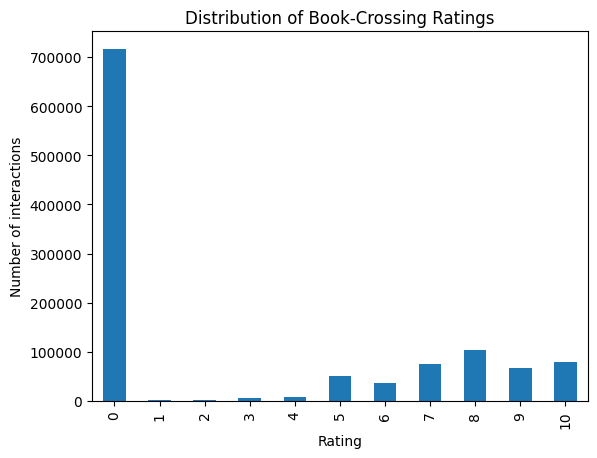

In [9]:
ratings["Rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of interactions")
plt.title("Distribution of Book-Crossing Ratings")
plt.show()

I want to see the actual ratings without the non-ratings.  I don't want to discard that data as it may be useful later, but I do want to see how the actual ratings have been distributed.

In [10]:
actual_ratings = ratings[
    ratings["Rating"] > 0
].copy()

Non_ratings = ratings[
    ratings["Rating"] == 0
].copy()

print("Actual Ratings:", len(actual_ratings))
print("Basic Interactions:", len(Non_ratings))

Actual Ratings: 433671
Basic Interactions: 716109


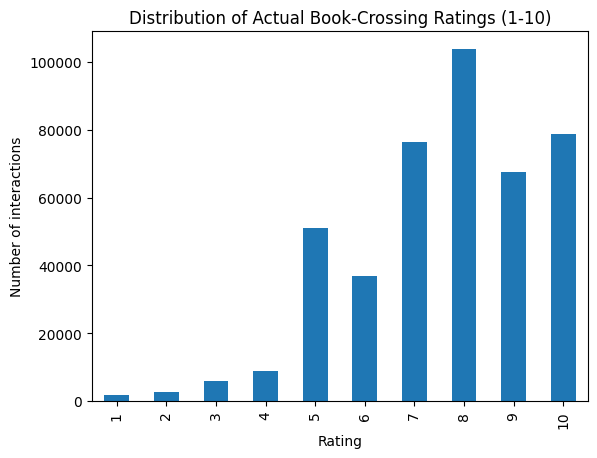

In [11]:
actual_ratings["Rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of interactions")
plt.title("Distribution of Actual Book-Crossing Ratings (1-10)")
plt.show()

I want to check the updated user ages.

In [12]:
users["Age"].describe()

,Age
count,278858
unique,312
top,Not Given
freq,110231


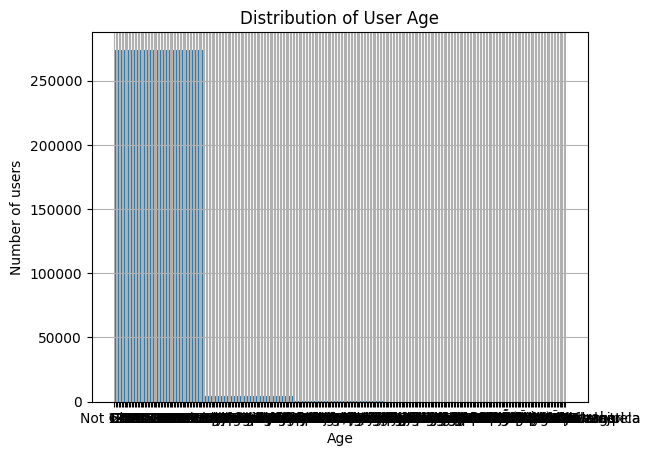

In [13]:
users["Age"].hist(bins=5)

plt.xlabel("Age")
plt.ylabel("Number of users")
plt.title("Distribution of User Age")
plt.show()

My original decision to change the blank ages to "Not Given" was not a good choice.  I'm changing them back to numbers and adding an extra column for age groups.  Those ages currently shown as "Not Given" will be adjusted to zero in the original column.

In [14]:
# 1. Convert 'Age' column back to numeric, replacing 'Not Given' with 0
users["Age"] = pd.to_numeric(users["Age"].replace("Not Given", 0), errors="coerce").fillna(0).astype(int)

# Define age group boundaries and labels
bins = [-1, 0, 17, 35, 50, 65, 120]
labels = ["Unknown", "Under 18", "18-35", "36-50", "51-65", "65+"]

# 2. Add an extra column for age groups
users["Age_Group"] = pd.cut(users["Age"], bins=bins, labels=labels)

# 3. Print the summary and display the head of the updated DataFrame
print("Users by Age Group:")
print(users["Age_Group"].value_counts().sort_index())
display(users.head(10))

Users by Age Group:
Age_Group
Unknown     112119
Under 18     11833
18-35        86573
36-50        42929
51-65        21377
65+           3949
Name: count, dtype: int64


,User-ID,Age,Age_Group
0,1,0,Unknown
1,2,18,18-35
2,3,0,Unknown
3,4,17,Under 18
4,5,0,Unknown
5,6,61,51-65
6,7,0,Unknown
7,8,0,Unknown
8,9,0,Unknown
9,10,26,18-35


Now I will look at the age distribution chart again.

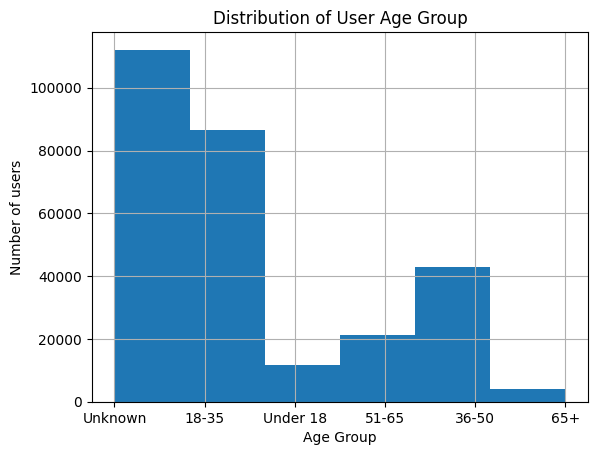

In [15]:
users["Age_Group"].hist(bins=6)

plt.xlabel("Age Group")
plt.ylabel("Number of users")
plt.title("Distribution of User Age Group")
plt.show()

I'm going to merge the actual ratings with the users and books so that I can see all the information together.

In [16]:
df = actual_ratings.merge(
    users,
    on="User-ID",
    how="left"
)

df = df.merge(
    books,
    on="ISBN",
    how="left"
)

print(df.shape)
display(df.head())

(433671, 9)


,User-ID,ISBN,Rating,Age,Age_Group,Title,Author,Year,Publisher
0,276726,0155061224,5,0,Unknown,Rites of Passage,Judith Rae,2001.0,Heinle
1,276729,052165615X,3,16,Under 18,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press
2,276729,0521795028,6,16,Under 18,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press
3,276736,3257224281,8,0,Unknown,NaN,NaN,NaN,NaN
4,276737,0600570967,6,14,Under 18,NaN,NaN,NaN,NaN


The NaN entries show that some users have rated books that are not in my list of books.   I will find out how many of these exist.

In [18]:
# Calculate the number and percentage of rating entries with missing book information
missing_books_count = df["Title"].isnull().sum()
total_ratings_count = len(df)
percentage_missing = (missing_books_count / total_ratings_count) * 100

print(f"Total rated transactions: {total_ratings_count}")
print(f"Ratings with no matching book record (NaNs): {missing_books_count} ({percentage_missing:.2f}%)")

Total rated transactions: 433671
Ratings with no matching book record (NaNs): 49819 (11.49%)


The answer is 49,819 - 11.49% of my records.  I think I'm happy to lose these to preserve data integrity and consistency.

In [19]:
# Drop rows where book metadata is missing (NaNs in Title, Author, Year, or Publisher)
df_clean = df.dropna(subset=["Title", "Author", "Year", "Publisher"])

print(f"Original df shape: {df.shape}")
print(f"Cleaned df shape: {df_clean.shape}")
print(f"Removed {len(df) - len(df_clean)} records with missing book details.")

# Quick confirmation that no NaNs remain
print("\nRemaining missing values per column in df_clean:")
print(df_clean.isnull().sum())

Original df shape: (433671, 9)
Cleaned df shape: (383852, 9)
Removed 49819 records with missing book details.

Remaining missing values per column in df_clean:
User-ID        0
ISBN           0
Rating         0
Age            0
Age_Group    303
Title          0
Author         0
Year           0
Publisher      0
dtype: int64


The above numbers tell me that I have some users who were not included in my age group classification.  Let's look at these.

In [20]:
# Inspect rows in df_clean where Age_Group is NaN to see their actual Age values
mismatched_ages = df_clean[df_clean["Age_Group"].isnull()]["Age"]
print("Unique age values causing NaN in Age_Group:")
print(mismatched_ages.unique())
print(f"\nTotal instances with these ages: {len(mismatched_ages)}")

Unique age values causing NaN in Age_Group:
[239 151 201 244 128 141 219 133 209 212 237 136 199 147 148 132 152 226
 229 138 228 223 146 204 220 200 140]

Total instances with these ages: 303


It seems highly unlikely that these are genuine ages, so I'll add them to the "Unknown" group.

In [21]:
# Map any NaN age group values (extreme ages outside our 0-120 limit) to the 'Unknown' group
if "Age_Group" in df_clean.columns:
    # Since Age_Group is a categorical column, we can fill NaN values with 'Unknown'
    df_clean["Age_Group"] = df_clean["Age_Group"].fillna("Unknown")

    # Do the same for our base users dataframe to keep things synchronized
    users["Age_Group"] = users["Age_Group"].fillna("Unknown")

# Confirm that no missing values remain in the Age_Group column
print("Remaining missing values in df_clean['Age_Group']:", df_clean["Age_Group"].isnull().sum())
print("\nUpdated Age Group distribution in df_clean:")
print(df_clean["Age_Group"].value_counts().sort_index())

Remaining missing values in df_clean['Age_Group']: 0

Updated Age Group distribution in df_clean:
Age_Group
Unknown     115967
Under 18     10148
18-35       130929
36-50        85099
51-65        36974
65+           4735
Name: count, dtype: int64


/tmp/ipykernel_2336/2907349728.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Age_Group"] = df_clean["Age_Group"].fillna("Unknown")


Re-running age group distribution chart:

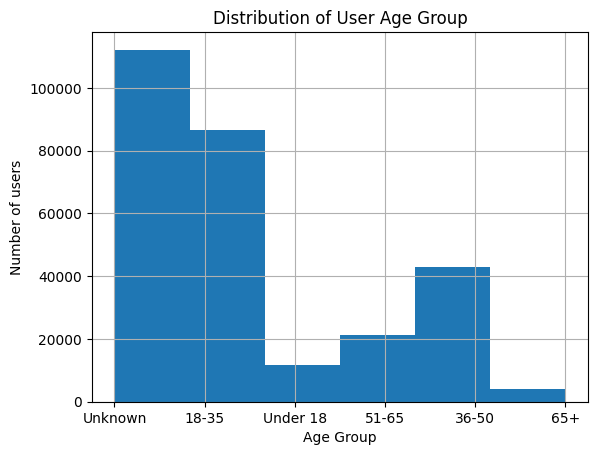

In [22]:
users["Age_Group"].hist(bins=6)

plt.xlabel("Age Group")
plt.ylabel("Number of users")
plt.title("Distribution of User Age Group")
plt.show()

Reviewing the data post clean-up

In [43]:
# Display the head of the cleaned DataFrame (df_clean) which has no NaN values
print(df_clean.head().to_string(index=False))

 User-ID       ISBN  Rating  Age Age_Group                                                          Title        Author   Year                  Publisher  User_Actual_Count Activity_Group
  276726 0155061224       5    0   Unknown                                               Rites of Passage    Judith Rae 2001.0                     Heinle                  1            Low
  276729 052165615X       3   16  Under 18                                                 Help!: Level 1 Philip Prowse 1999.0 Cambridge University Press                  2            Low
  276729 0521795028       6   16  Under 18 The Amsterdam Connection : Level 4 (Cambridge English Readers)   Sue Leather 2001.0 Cambridge University Press                  2            Low
  276744 038550120X       7    0   Unknown                                                A Painted House  JOHN GRISHAM 2001.0                  Doubleday                  1            Low
  276747 0060517794       9   25     18-35                  

How many ratings (including non-ratings) has each user provided?

In [45]:
# Display the number of ratings per user
user_activity = (
    df.groupby("User-ID")
      .size()
      .sort_values(ascending=False)
)

user_activity.describe()

,0
count,77805.000000
mean,5.573819
std,44.001879
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,8524.000000


Over half of our users have rated only one book.  The most prolific user has "rated" over 8.5k - this suggests this user has simply looked up a lot of books.

How many ratings does each book have?

In [46]:
#Display the number of ratings per book
book_activity = (
    df.groupby("ISBN")
      .size()
      .sort_values(ascending=False)
)

book_activity.describe()

,0
count,185973.000000
mean,2.331903
std,6.834667
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,707.000000


Again, over half of the books have only one rating entry, with the highest number of ratings for any ISBN being 707.

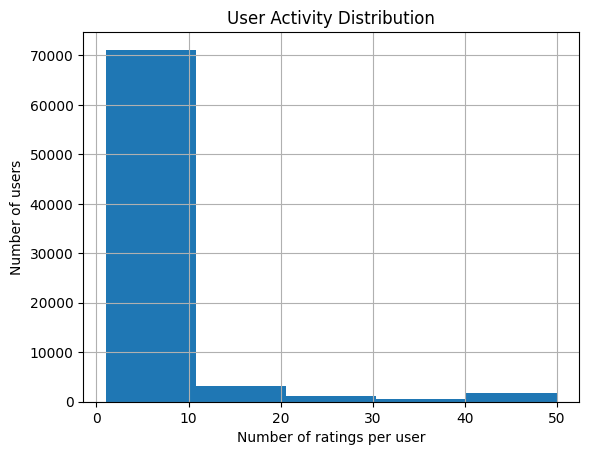

In [47]:
user_activity.clip(upper=50).hist(bins=5)

plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users")
plt.title("User Activity Distribution")
plt.show()

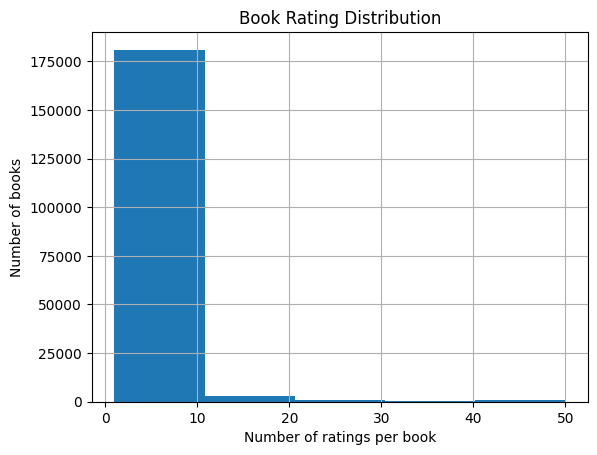

In [28]:
book_activity.clip(upper=50).hist(bins=5)

plt.xlabel("Number of ratings per book")
plt.ylabel("Number of books")
plt.title("Book Rating Distribution")
plt.show()

As there are many books with only one rating and many users who've given only one rating, this means that much of our data is individual, making predictions based on the data difficult to ascertain.

How many users have reviewed multiple books?

In [48]:
user_counts = df.groupby("User-ID").size()

df["User-Rating-Count"] = (
    df["User-ID"].map(user_counts)
)

In [30]:
user_counts.describe(
    percentiles=[.25, .5, .75, .9, .95]
)

,0
count,77805.000000
mean,5.573819
std,44.001879
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
90%,9.000000
95%,19.000000
max,8524.000000


I'm going to categorise the users into low, medium and high activity

In [31]:
# Calculate the rating count per user based on our cleaned actual ratings dataset
user_actual_counts = df_clean.groupby("User-ID").size()

# Map the actual rating counts to our df_clean dataframe
df_clean["User_Actual_Count"] = df_clean["User-ID"].map(user_actual_counts)

# Define the binning function for user activity groups
def assign_activity_group(count):
    if count < 3:
        return "Low"
    elif count <= 9:
        return "Medium"
    else:
        return "High"

# Apply the classification
df_clean["Activity_Group"] = df_clean["User_Actual_Count"].apply(assign_activity_group)

# Display the count of rating transactions belonging to each group
print("Number of ratings by User Activity Group:")
print(df_clean["Activity_Group"].value_counts())

# Display a brief sample of the updated dataframe
display(df_clean[["User-ID", "ISBN", "Rating", "User_Actual_Count", "Activity_Group"]].head())

Number of ratings by User Activity Group:
Activity_Group
High      261908
Medium     65372
Low        56572
Name: count, dtype: int64


,User-ID,ISBN,Rating,User_Actual_Count,Activity_Group
0,276726,0155061224,5,1,Low
1,276729,052165615X,3,2,Low
2,276729,0521795028,6,2,Low
5,276744,038550120X,7,1,Low
7,276747,0060517794,9,5,Medium


All data cleaning and preparations are now complete. Here is a recap of the current dataset:

df_clean: Contains 383,852 explicit rating transactions (scaled 1-10) with complete metadata.
Books Catalog: All rated books have resolved titles, authors, and publishers.
Demographics: Users have valid age variables mapped into categorized groups, with extreme/missing values properly labeled as 'Unknown'.

I will now create my Traditional SVD model.  I'm going to use a traditional 80/20 split for train and test splits.

In [49]:
!pip install scikit-surprise --quiet

from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# 1. Prepare data for the surprise library
reader = Reader(rating_scale=(1, 10))
surprise_data = Dataset.load_from_df(df_clean[['User-ID', 'ISBN', 'Rating']], reader)

# 2. Split dataset into 80% train and 20% test sets
trainset, testset = train_test_split(surprise_data, test_size=0.2, random_state=42)

# 3. Instantiate and train the SVD model
svd_model = SVD(random_state=42)
print("Training the traditional SVD model...")
svd_model.fit(trainset)

# 4. Predict and evaluate
predictions = svd_model.test(testset)
print("\n--- SVD Evaluation Metrics ---")
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

Training the traditional SVD model...

--- SVD Evaluation Metrics ---
RMSE: 1.6345
MAE:  1.2629


RMSE = Root Mean Squared Error.  The values are squared, meaning that the number is higher than the MAE for the same errors.  0 is perfection.

MAE = Mean Absolute Error.  An MAE of 1.26 means that the predicted rating is different to the actualy rating by roughly 1.26 rating points.  The number is lower than the RMSE for the same errors because the numbers are not squared. 0 is perfection.

In [50]:
results = pd.DataFrame({
    "Model": ["SVD"],
    "RMSE": [rmse],
    "MAE": [mae]
})

results

,Model,RMSE,MAE
0,SVD,1.634455,1.262921


In [51]:
# Run some actual predictions
import pandas as pd

results = pd.DataFrame([
    {
        'User-ID': pred.uid,
        'ISBN': pred.iid,
        'Actual Rating': pred.r_ui,
        'Predicted Rating': pred.est,
        'Error': abs(pred.r_ui - pred.est)
    }
    for pred in predictions
])

results.head(10)

,User-ID,ISBN,Actual Rating,Predicted Rating,Error
0,151503,0345386744,6.0,6.327359,0.327359
1,112001,0380769840,10.0,9.421026,0.578974
2,138844,0425167313,7.0,7.496114,0.496114
3,212328,0394860152,8.0,7.544292,0.455708
4,210587,0316735027,10.0,7.517934,2.482066
5,227161,0671813919,1.0,6.711188,5.711188
6,179978,0736421130,10.0,8.735078,1.264922
7,163187,1570719446,8.0,7.314210,0.685790
8,217375,0345453816,9.0,7.594883,1.405117
9,106018,0767900553,9.0,7.764136,1.235864


Some of these errors are quite large - 5.7 and some are small - 0.3.

In [53]:
#Best Predictions
results.sort_values('Error').head(20)

,User-ID,ISBN,Actual Rating,Predicted Rating,Error
16066,156467,0515128546,10.0,10.0,0.0
37334,88229,0142001740,10.0,10.0,0.0
6603,52614,0312992416,10.0,10.0,0.0
31357,31826,0671793489,10.0,10.0,0.0
50249,156300,0380720191,10.0,10.0,0.0
19221,206438,0451190572,10.0,10.0,0.0
73263,156300,0842329250,10.0,10.0,0.0
10805,182086,0380818051,10.0,10.0,0.0
5180,2030,0062509594,10.0,10.0,0.0
40414,31826,0451170385,10.0,10.0,0.0


In [55]:
# Worst predictions
results.sort_values('Error', ascending=False).head(20)

,User-ID,ISBN,Actual Rating,Predicted Rating,Error
14990,205735,0702227579,1.0,9.133685,8.133685
51681,118228,0446671002,1.0,9.115074,8.115074
69054,157811,0060392452,1.0,9.024678,8.024678
70514,168047,0394743121,1.0,9.001648,8.001648
19233,149907,0735201404,1.0,8.957025,7.957025
33110,118333,0679886370,2.0,9.824252,7.824252
75567,76499,0195027930,1.0,8.820418,7.820418
3488,76499,0534534651,1.0,8.820418,7.820418
56670,76499,041590451X,1.0,8.820418,7.820418
4902,76499,0806509023,1.0,8.820418,7.820418


In [36]:
# Prediction Description
prediction_df.describe()

,User-ID,Actual,Predicted,Error
count,76771.000000,76771.000000,76771.000000,76771.000000
mean,135632.689310,7.636503,7.696429,-0.059926
std,80471.452651,1.838420,0.813776,1.633367
min,19.000000,1.000000,1.863013,-8.133685
25%,67141.500000,7.000000,7.289021,-0.935711
50%,133416.000000,8.000000,7.665780,0.149987
75%,205448.000000,9.000000,8.159275,1.089960
max,278854.000000,10.000000,10.000000,5.740135


Let's look at the predictions vs actuals as a chart

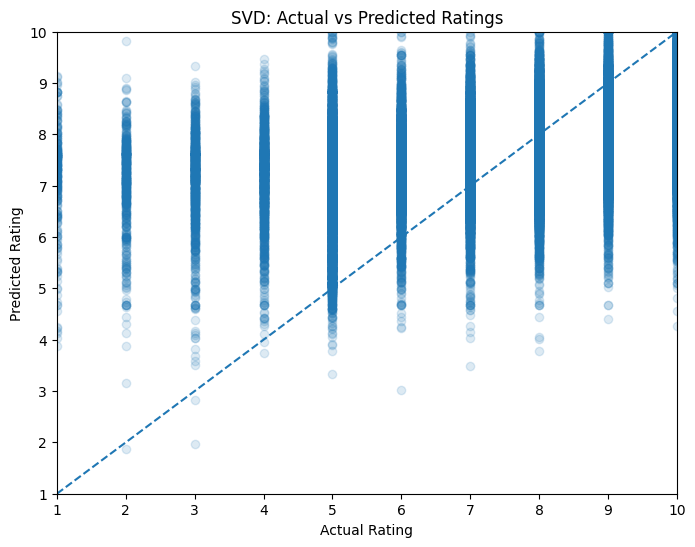

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_df["Actual"],
    prediction_df["Predicted"],
    alpha=0.15
)

plt.plot(
    [1, 10],
    [1, 10],
    linestyle="--"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("SVD: Actual vs Predicted Ratings")
plt.xlim(1, 10)
plt.ylim(1, 10)

plt.show()

- - - shows perfect predictions.  If this was a perfect model, then all datapoints would lie on the diagonal line.  This is a visual indication of the prediction error.

I used k-fold cross-validation to better evaluate the model. (Geron 2025).  I used five folds.

In [38]:
from surprise.model_selection import cross_validate

svd_cv = SVD(random_state=42)

cv_results = cross_validate(
    svd_cv,
    surprise_data,
    measures=["RMSE", "MAE"],
    cv=5,
    verbose=True
)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.6312  1.6396  1.6377  1.6308  1.6408  1.6360  0.0042  
MAE (testset)     1.2579  1.2670  1.2639  1.2584  1.2647  1.2624  0.0036  
Fit time          10.13   5.93    6.74    6.09    7.10    7.20    1.52    
Test time         0.38    0.49    1.26    0.56    0.85    0.70    0.32    


In [40]:
# Five fold chart
cv_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "RMSE": cv_results["test_rmse"],
    "MAE": cv_results["test_mae"]
})

cv_df

,Fold,RMSE,MAE
0,1,1.631158,1.257876
1,2,1.639552,1.267006
2,3,1.637672,1.263929
3,4,1.630822,1.258414
4,5,1.640785,1.264724


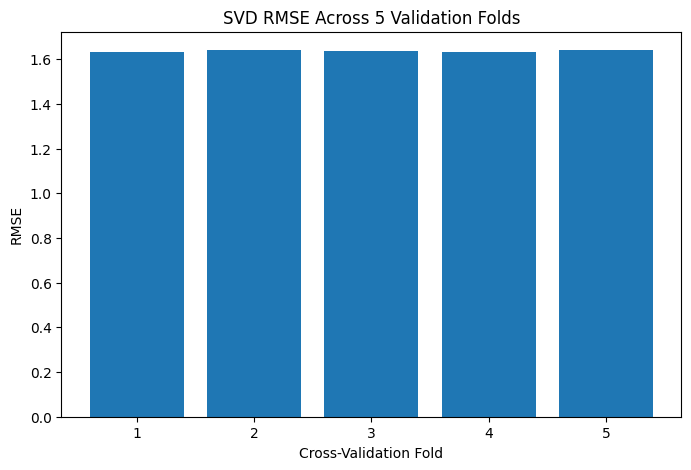

In [41]:
# Five fold graph
plt.figure(figsize=(8, 5))

plt.bar(
    cv_df["Fold"].astype(str),
    cv_df["RMSE"]
)

plt.xlabel("Cross-Validation Fold")
plt.ylabel("RMSE")
plt.title("SVD RMSE Across 5 Validation Folds")

plt.show()

These results are very similar to the training dataset RMSE and MAE, meaning that the model's generalisaton performance is stable.  I need to also compare this with the training data to confirm it's not overfitting.

In [56]:
svd_model.fit(trainset)

predictions = svd_model.test(testset)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 1.6345
MAE:  1.2629


In [57]:
# Test the model on the training data
train_predictions = svd_model.test(trainset.build_testset())

print("\n--- SVD Training Metrics ---")
train_rmse = accuracy.rmse(train_predictions)
train_mae = accuracy.mae(train_predictions)

print("\n--- SVD Test Metrics ---")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE:     {rmse:.4f}")
print(f"Training MAE:  {train_mae:.4f}")
print(f"Test MAE:      {mae:.4f}")


--- SVD Training Metrics ---
RMSE: 1.0009
MAE:  0.7645

--- SVD Test Metrics ---
Training RMSE: 1.0009
Test RMSE:     1.6345
Training MAE:  0.7645
Test MAE:      1.2629


There is a difference between the training and the unseen data numbers.  This is an example of overfitting.  The model has learned specific data from the training data that's not true in all the data.  The training RMSE is lower than the test RMSE, which shows that the model fits the training data, but not the unseen data.  Can this be improved?

In [59]:
# Adjust factors - fine tuning
from surprise import SVD, accuracy

# Create a more strongly regularised model
svd_tuned = SVD(
    n_factors=50,
    reg_all=0.1,
    random_state=42
)

# Train on EXACTLY the same training set as before
svd_tuned.fit(trainset)

In [60]:
# Re-evaluate
# Training predictions
train_predictions_tuned = svd_tuned.test(
    trainset.build_testset()
)

# Test predictions
test_predictions_tuned = svd_tuned.test(testset)

print("--- TUNED SVD: TRAINING ---")
train_rmse_tuned = accuracy.rmse(train_predictions_tuned)
train_mae_tuned = accuracy.mae(train_predictions_tuned)

print("\n--- TUNED SVD: TEST ---")
test_rmse_tuned = accuracy.rmse(test_predictions_tuned)
test_mae_tuned = accuracy.mae(test_predictions_tuned)

--- TUNED SVD: TRAINING ---
RMSE: 1.2720
MAE:  0.9927

--- TUNED SVD: TEST ---
RMSE: 1.6255
MAE:  1.2607


I'm going to now compare this to my original model

In [61]:
# Compare models
print("\n--- MODEL COMPARISON ---")
print(f"{'Metric':<18} {'Original':>10} {'Tuned':>10}")
print("-" * 40)
print(f"{'Training RMSE':<18} {1.0009:>10.4f} {train_rmse_tuned:>10.4f}")
print(f"{'Test RMSE':<18} {1.6345:>10.4f} {test_rmse_tuned:>10.4f}")
print(f"{'Training MAE':<18} {0.7645:>10.4f} {train_mae_tuned:>10.4f}")
print(f"{'Test MAE':<18} {1.2629:>10.4f} {test_mae_tuned:>10.4f}")


--- MODEL COMPARISON ---
Metric               Original      Tuned
----------------------------------------
Training RMSE          1.0009     1.2720
Test RMSE              1.6345     1.6255
Training MAE           0.7645     0.9927
Test MAE               1.2629     1.2607


The tuning has improved the model.  Training performance is worse - expected because it previously fit too well.  Unseen performance is better.  This is a better fit overall.  It's only a small change, but it's in the right direction

Calculate NDCG@10 - Normalised discounted Cumulative Gain (Top 10).  Checks how good ranking is. Rankings are 0-1.  1 is best, 0 is worst.

In [62]:
from sklearn.metrics import ndcg_score
import numpy as np

ndcg_scores = []

for user_id, group in prediction_df.groupby("User-ID"):

    # Need more than one item for ranking to be meaningful
    if len(group) < 2:
        continue

    actual = group["Actual"].values.reshape(1, -1)
    predicted = group["Predicted"].values.reshape(1, -1)

    score = ndcg_score(
        actual,
        predicted,
        k=10
    )

    ndcg_scores.append(score)

mean_ndcg = np.mean(ndcg_scores)

print(f"Mean NDCG@10: {mean_ndcg:.4f}")
print(f"Users evaluated: {len(ndcg_scores)}")

Mean NDCG@10: 0.9598
Users evaluated: 9487


This score is very high, suggesting top 10 recommendations are very good.  This is much better than the RMSE score.  Is it correct?

How many test items does each evaluated user actually have?

In [63]:
items_per_user = prediction_df.groupby("User-ID").size()

print(items_per_user.describe())

print("\nUsers with fewer than 10 test items:")
print((items_per_user < 10).sum())

print("\nUsers with 10 or more test items:")
print((items_per_user >= 10).sum())

count    25748.000000
mean         2.981630
std         13.786709
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max       1383.000000
dtype: float64

Users with fewer than 10 test items:
24428

Users with 10 or more test items:
1320


A lot of users have less than ten test items (24,428)  This could be skewing the NDCG result.  As the majority of users have only one item and I've looked at users with 2 and above, let's now look at users with 10 and above items.

In [64]:
# NDCG@10 - users with 10 or greater ratings
from sklearn.metrics import ndcg_score
import numpy as np

ndcg_scores_10plus = []

for user_id, group in prediction_df.groupby("User-ID"):

    # Only evaluate users with at least 10 test items
    if len(group) < 10:
        continue

    actual = group["Actual"].values.reshape(1, -1)
    predicted = group["Predicted"].values.reshape(1, -1)

    score = ndcg_score(
        actual,
        predicted,
        k=10
    )

    ndcg_scores_10plus.append(score)

mean_ndcg_10plus = np.mean(ndcg_scores_10plus)

print(f"Mean NDCG@10: {mean_ndcg_10plus:.4f}")
print(f"Users evaluated: {len(ndcg_scores_10plus)}")

Mean NDCG@10: 0.9010
Users evaluated: 1320


Initial NDCG@10 was 0.9598.  Most users had only 1 rating - only 1,320 had ten or more items in the test set.  This highlights the impact of data sparsity when evaluating recommender systems.  With the 1,320 users, the NDCG@10 changed to 0.9010.  This is still a strong score, but should be interpeted with caution.  There are many books that have not been rated and so would not be recommended.  This dataset doesn't hold much book information such as genre that would help to classify it and its ratings.

I split the data using the traditional 80/20.  Would a different split have given better results?

It's time to move on to the Deep Learning Model using TensorFlow and Keras

User ID → User Embedding ─┐
                            
Book ISBN → Book Embedding┘

├→ Concatenate → Dense → Dense → Rating

In [72]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Preprocess IDs to continuous integers for Embedding Layers
user_encoder = LabelEncoder()
book_encoder = LabelEncoder()

# Create a copy to prevent SettingWithCopyWarning
df_dl = df_clean.copy()

df_dl["user_idx"] = user_encoder.fit_transform(df_dl["User-ID"])
df_dl["book_idx"] = book_encoder.fit_transform(df_dl["ISBN"])

num_users = df_dl["user_idx"].nunique()
num_books = df_dl["book_idx"].nunique()

print(f"Total unique users: {num_users}")
print(f"Total unique books: {num_books}")

# 2. Split dataset (80/20 train/test split to match the SVD evaluation pipeline)
X_train, X_test, y_train, y_test = train_test_split(
    df_dl[["user_idx", "book_idx"]],
    df_dl["Rating"].values,
    test_size=0.2,
    random_state=42
)

# Prepare inputs
train_user_input = X_train["user_idx"].values
train_book_input = X_train["book_idx"].values

test_user_input = X_test["user_idx"].values
test_book_input = X_test["book_idx"].values

Total unique users: 68092
Total unique books: 149842


In [73]:
# 3. Define the Deep Learning Model Architecture
embedding_dim = 15

# Inputs
user_input = Input(shape=(1,), name="User_Input")
book_input = Input(shape=(1,), name="Book_Input")

# Embeddings
user_embedding = Embedding(input_dim=num_users, output_dim=embedding_dim, name="User_Embedding")(user_input)
book_embedding = Embedding(input_dim=num_books, output_dim=embedding_dim, name="Book_Embedding")(book_input)

# Flatten representations
user_flat = Flatten()(user_embedding)
book_flat = Flatten()(book_embedding)

# Concatenate representations
concat = Concatenate()([user_flat, book_flat])

# Dense Layers
dense_1 = Dense(64, activation="relu")(concat)
drop_1 = Dropout(0.2)(dense_1)
dense_2 = Dense(16, activation="relu")(drop_1)
output = Dense(1)(dense_2)  # Regressing directly to the rating (1 to 10)

# Assemble & Compile Model
dl_model = Model(inputs=[user_input, book_input], outputs=output)
dl_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])

dl_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ User_Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Book_Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User_Embedding      │ (None, 1, 15)     │  1,021,380 │ User_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Book_Embedding      │ (None, 1, 15)     │  2,247,630 │ Book_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 15)        │          0 │ User_Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 15)        │          0 │ Book_Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 30)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      1,984 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │      1,040 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         17 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,272,051 (12.48 MB)

 Trainable params: 3,272,051 (12.48 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# 4. Train the Deep Learning Model
history = dl_model.fit(
    [train_user_input, train_book_input],
    y_train,
    batch_size=512,
    epochs=5,
    validation_data=([test_user_input, test_book_input], y_test),
    verbose=1
)

Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 10.4724 - mean_absolute_error: 2.2987 - val_loss: 2.7356 - val_mean_absolute_error: 1.2856
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 2.4345 - mean_absolute_error: 1.2047 - val_loss: 2.7789 - val_mean_absolute_error: 1.2918
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 1.9259 - mean_absolute_error: 1.0562 - val_loss: 2.8784 - val_mean_absolute_error: 1.3131
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 1.6675 - mean_absolute_error: 0.9728 - val_loss: 2.9518 - val_mean_absolute_error: 1.3280
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 1.4850 - mean_absolute_error: 0.9053 - val_loss: 3.0225 - val_mean_absolute_error: 1.3317


In [75]:
# 5. Evaluate the Deep Learning Model and Compare
import numpy as np

dl_predictions = dl_model.predict([test_user_input, test_book_input]).flatten()

# Compute Metrics
dl_rmse = np.sqrt(np.mean((y_test - dl_predictions) ** 2))
dl_mae = np.mean(np.abs(y_test - dl_predictions))

print("\n--- Deep Learning (NCF) Evaluation Metrics ---")
print(f"RMSE: {dl_rmse:.4f}")
print(f"MAE:  {dl_mae:.4f}")

2400/2400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

--- Deep Learning (NCF) Evaluation Metrics ---
RMSE: 1.7385
MAE:  1.3317


In [76]:
from sklearn.metrics import ndcg_score
import numpy as np
import pandas as pd

# Create a DataFrame to hold test actuals and NCF predictions
ncf_pred_df = pd.DataFrame({
    'User-ID': X_test['user_idx'].values,
    'Actual': y_test,
    'Predicted': dl_predictions
})

ndcg_scores_ncf = []

for user_id, group in ncf_pred_df.groupby("User-ID"):
    # We need more than one item for ranking to be meaningful
    if len(group) < 2:
        continue

    actual = group["Actual"].values.reshape(1, -1)
    predicted = group["Predicted"].values.reshape(1, -1)

    score = ndcg_score(actual, predicted, k=10)
    ndcg_scores_ncf.append(score)

mean_ndcg_ncf = np.mean(ndcg_scores_ncf)
print(f"NCF Mean NDCG@10 (2+ ratings): {mean_ndcg_ncf:.4f}")
print(f"Users evaluated: {len(ndcg_scores_ncf)}")

# Now calculate for users with 10 or more ratings in the test set
ndcg_scores_ncf_10plus = []

for user_id, group in ncf_pred_df.groupby("User-ID"):
    if len(group) < 10:
        continue

    actual = group["Actual"].values.reshape(1, -1)
    predicted = group["Predicted"].values.reshape(1, -1)

    score = ndcg_score(actual, predicted, k=10)
    ndcg_scores_ncf_10plus.append(score)

mean_ndcg_ncf_10plus = np.mean(ndcg_scores_ncf_10plus)
print(f"\nNCF Mean NDCG@10 (10+ ratings): {mean_ndcg_ncf_10plus:.4f}")
print(f"Users evaluated (10+): {len(ndcg_scores_ncf_10plus)}")

NCF Mean NDCG@10 (2+ ratings): 0.9599
Users evaluated: 9431

NCF Mean NDCG@10 (10+ ratings): 0.9046
Users evaluated (10+): 1325


RMSE: 1.7275
MAE: 1.3294
NDCG@10 (2+ ratings) 0.9603 9431 users
NDCG@10 (10+ ratings) 0.9045  1325 users

RMSE = Root Mean Squared Error.  The values are squared, meaning that the number is higher than the MAE for the same errors.  0 is perfection.

MAE = Mean Absolute Error.  An MAE of 1.32 means that the predicted rating is different to the actualy rating by roughly 1.32 rating points.  The number is lower than the RMSE for the same errors because the numbers are not squared. 0 is perfection.

NDCG@10 - Normalised discounted Cumulative Gain (Top 10). Checks how good ranking is. Rankings are 0-1. 1 is best, 0 is worst.

Let's look at some actual predictions


In [78]:
# Generate predictions for the test set
predictions = dl_model.predict(
    [X_test['user_idx'].values, X_test['book_idx'].values],
    verbose=0
).flatten()

# Create a dataframe comparing actual and predicted ratings
prediction_examples = pd.DataFrame({
    'Actual Rating': y_test,
    'Predicted Rating': predictions
})

# Show 20 examples
prediction_examples.head(20)

,Actual Rating,Predicted Rating
0,9,6.672137
1,9,7.732080
2,1,6.207358
3,8,7.896468
4,10,9.513577
5,8,7.174693
6,10,8.193923
7,7,9.665195
8,5,6.704502
9,7,6.817386


In [80]:
# Reconstruct original identifiers from X_test index using df_dl
prediction_examples['User-ID'] = df_dl.loc[X_test.index, 'User-ID'].values
prediction_examples['ISBN'] = df_dl.loc[X_test.index, 'ISBN'].values

# Calculate the prediction error
prediction_examples['Error'] = abs(
    prediction_examples['Actual Rating'] -
    prediction_examples['Predicted Rating']
)

# Reorder columns for readability and show 20 examples
prediction_examples = prediction_examples[['User-ID', 'ISBN', 'Actual Rating', 'Predicted Rating', 'Error']]
display(prediction_examples.head(20))

,User-ID,ISBN,Actual Rating,Predicted Rating,Error
0,155743,0553582747,9,6.672137,2.327863
1,261998,0312979983,9,7.732080,1.267920
2,276171,0140275169,1,6.207358,5.207358
3,14422,0786002913,8,7.896468,0.103532
4,52614,1569030022,10,9.513577,0.486423
5,93711,0373227264,8,7.174693,0.825307
6,53042,1400031354,10,8.193923,1.806077
7,56399,0140341315,7,9.665195,2.665195
8,202885,0515095826,5,6.704502,1.704502
9,173460,8495808021,7,6.817386,0.182614


Best and worst predictions?

In [81]:
# Best predictions
prediction_examples.sort_values('Error').head(20)

,User-ID,ISBN,Actual Rating,Predicted Rating,Error
46146,94261,1568650108,8,8.000010,0.000010
39746,197659,0425121011,8,7.999976,0.000024
74706,249628,0966455800,8,7.999957,0.000043
45548,258266,0679429220,8,7.999918,0.000082
33038,128071,0842377506,10,10.000135,0.000135
30005,76483,0789403072,8,8.000152,0.000152
39944,209756,0679731156,7,7.000195,0.000195
60657,4385,0373225202,10,9.999800,0.000200
58723,218241,0696217120,7,7.000213,0.000213
70880,70201,0375706771,8,8.000218,0.000218


In [83]:
# Worst predictions
prediction_examples.sort_values('Error', ascending=False).head(20)

,User-ID,ISBN,Actual Rating,Predicted Rating,Error
27882,11601,0609800906,1,9.825719,8.825719
45566,27304,1853260207,1,9.804462,8.804462
61687,155778,0525947647,1,9.686301,8.686301
56975,96473,0440412919,1,9.536949,8.536949
19667,38273,0590464388,1,9.353772,8.353772
3331,116318,0312262140,1,9.339079,8.339079
38808,34175,0440986591,1,9.307415,8.307415
26255,248772,0517593483,10,1.708986,8.291014
31225,23872,0822003376,1,9.231037,8.231037
52107,169613,0679600116,1,9.196331,8.196331
